In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. DATA LOAD & SORTING

In [3]:
file_path = r'/content/preprocessed_demand_data (1) (2).csv'
df = pd.read_csv(file_path)

Date column-ah datetime-ah maathi, chronological order-la sort pannrom

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

/tmp/ipykernel_613/432272015.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


FEATURE SELECTION


In [5]:
target = 'OrderCount'

Data Leakage thaduka 'NumberOfPieces' and 'TotalRevenue'-ah thookiyachu!

In [6]:
features = [
    'Holiday_Indicator_Encoded', 'Festival_Name_Encoded', 'Season_Encoded',
    'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'IsWeekend', 'Quarter',
    'OrderCount_lag_1', 'OrderCount_lag_7', 'OrderCount_lag_14',
    'OrderCount_rolling_mean_7', 'OrderCount_rolling_std_7'
]

categorical_features = ['Hub', 'Region']

In [7]:
for col in categorical_features:
    df[col] = df[col].astype('category')

all_features = features + categorical_features

X = df[all_features]
y = df[target]


TIME-SERIES TRAIN & TEST SPLIT


In [8]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


XGBoost MODEL TRAINING

In [9]:
print("Training XGBoost model...")

Training XGBoost model...


In [10]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    random_state=42,
    early_stopping_rounds=50
)

Model fitting with validation tracking

In [11]:
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)


[0]	validation_0-rmse:185.27383	validation_1-rmse:201.08801
[100]	validation_0-rmse:39.21882	validation_1-rmse:64.72701
[145]	validation_0-rmse:35.76264	validation_1-rmse:64.86107


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

PREDICTION & EVALUATION

In [12]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- XGBoost Model Evaluation ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")


--- XGBoost Model Evaluation ---
RMSE: 64.6055
MAE: 43.6905
R2 Score: 0.9044


FEATURE IMPORTANCE


In [13]:
importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Important Features ---")
print(importance.head(5))


--- Top 5 Important Features ---
                      Feature  Importance
6                   DayOfWeek    0.613652
8                   IsWeekend    0.149362
13  OrderCount_rolling_mean_7    0.061122
12          OrderCount_lag_14    0.050928
11           OrderCount_lag_7    0.049069


Histogram (Shipment Volume Distribution)

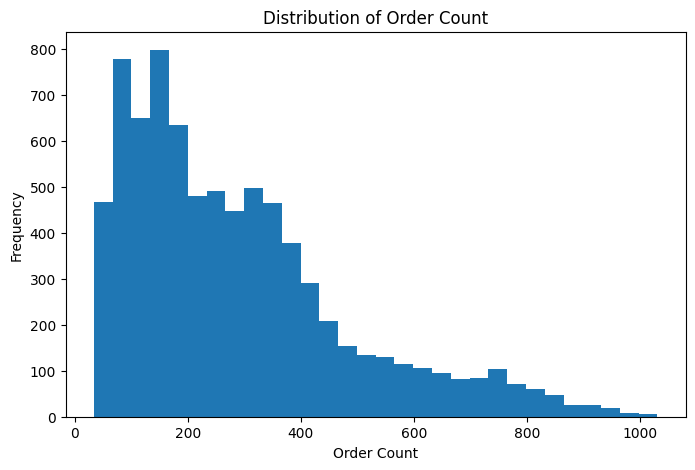

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['OrderCount'], bins=30)

plt.title("Distribution of Order Count")
plt.xlabel("Order Count")
plt.ylabel("Frequency")

plt.show()

Correlation Heatmap

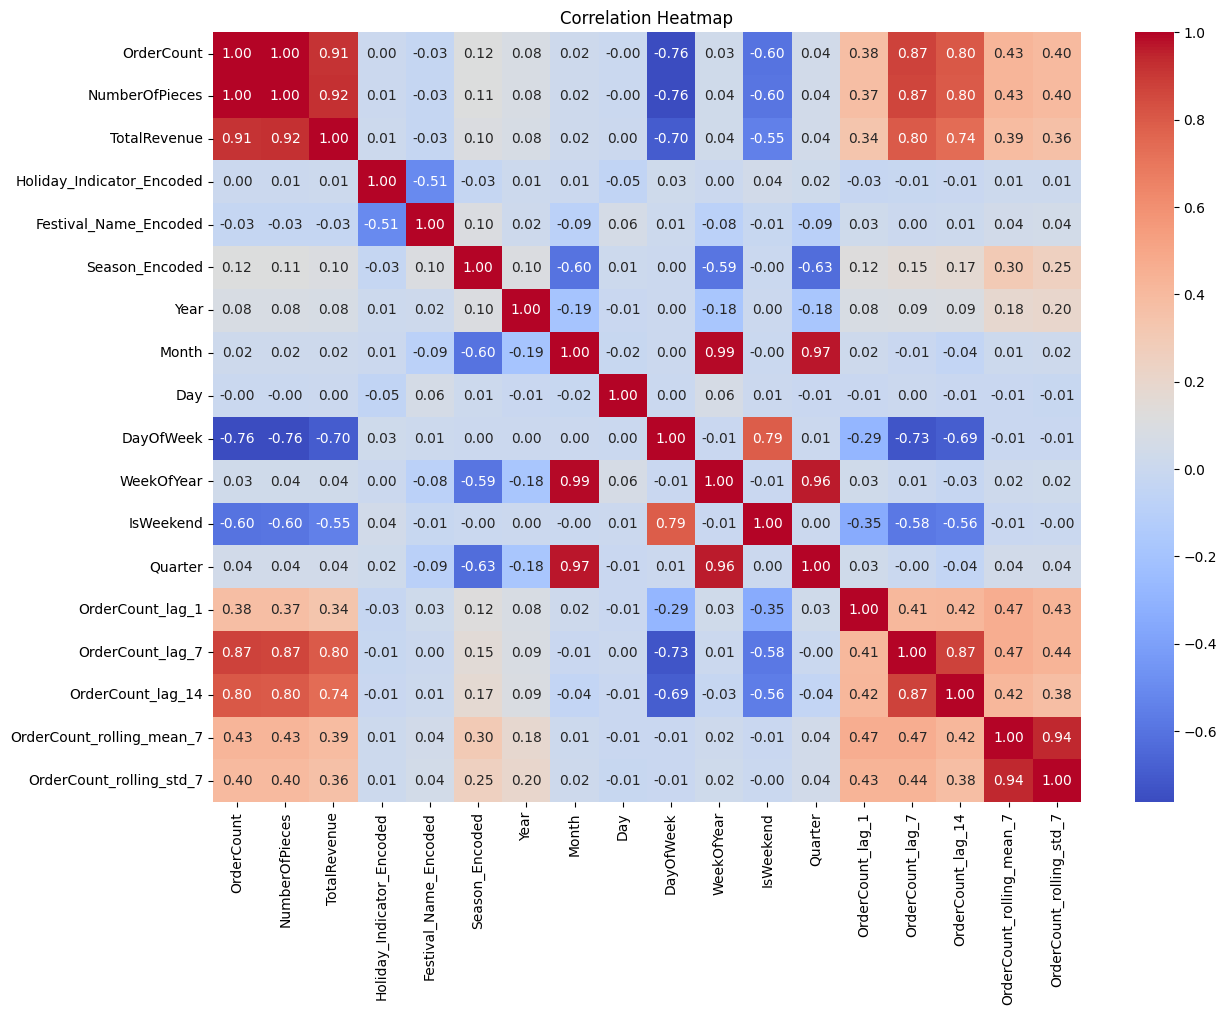

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

Scatter Plot

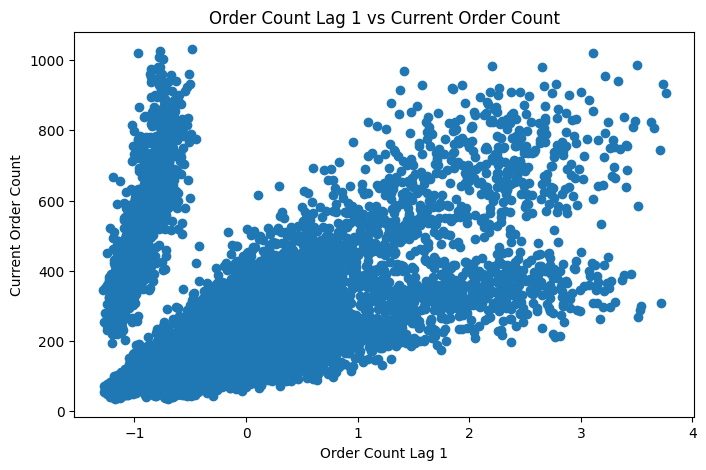

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df['OrderCount_lag_1'],
    df['OrderCount']
)

plt.title("Order Count Lag 1 vs Current Order Count")
plt.xlabel("Order Count Lag 1")
plt.ylabel("Current Order Count")

plt.show()